# Лабораторная работа: предобработка и анализ данных с использованием pandas

**Тема датасета:** клиенты интернет-магазина.

**Цель работы:** на синтетическом наборе данных отработать полный цикл предобработки табличных данных средствами `pandas`/`numpy`: загрузку, первичное изучение, изменение структуры (reshape, merge, кодирование категориальных признаков), очистку от дублей, пропусков и выбросов, визуализацию, корреляционный и статистический анализ зависимостей.

Датасет генерируется вручную с помощью `numpy.random` (без `sklearn.datasets`), в него намеренно закладываются пропуски (~5% значений в нескольких столбцах), явные выбросы (10–15 значений в числовых столбцах) и дубликаты строк (3–5% от объёма), чтобы каждый последующий шаг предобработки имел содержательный смысл, а не выполнялся "для галочки" на уже чистых данных.

## 1. Загрузка данных

In [1]:
# Импортируем библиотеки, необходимые для всей работы.
# numpy используется для генерации случайных чисел и векторных вычислений — он быстрее
# и удобнее, чем стандартный модуль random, поскольку работает сразу с массивами (векторизация),
# а не поэлементно в цикле Python.
# pandas — основной инструмент работы с табличными данными (DataFrame/Series).
# matplotlib.pyplot и seaborn — визуализация: matplotlib даёт низкоуровневый контроль над графиком,
# seaborn — более высокоуровневые статистические графики (например, scatterplot с раскраской по категории)
# с приятным оформлением "из коробки", поэтому оба используются совместно, а не только один из них.
# scipy.stats.chi2_contingency — реализация критерия хи-квадрат Пирсона для проверки независимости
# категориальных признаков (нужен в разделе 10); выбран scipy, а не ручная реализация формулы,
# так как это стандартная, проверенная и быстрая реализация, применяемая в промышленном анализе данных.
# sklearn.preprocessing — эталонные реализации LabelEncoder / OneHotEncoder для сравнения
# с "ручными" способами кодирования pandas (pd.Categorical, pd.get_dummies).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Фиксируем seed генератора случайных чисел, чтобы результаты были воспроизводимы:
# при повторном запуске ноутбука датасет и все дальнейшие вычисления (в т.ч. случайные выборки
# для выбросов/дублей) будут идентичны, что важно для проверки и защиты работы.
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Настройки отображения pandas: показываем все столбцы и ограничиваем ширину,
# чтобы широкий датасет было удобно читать в выводе ячеек.
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# Единый стиль графиков для всего ноутбука.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# ---------------------------------------------------------------------------
# Генерация синтетического датасета "клиенты интернет-магазина".
# ---------------------------------------------------------------------------
# Размер базовой (без дублей) выборки — 650 строк, что попадает в требуемый диапазон 500-800.
N_BASE = 650

# customer_id: уникальный целочисленный идентификатор клиента (аналог первичного ключа в БД).
# Используем np.arange, а не np.random.randint с последующим удалением повторов, потому что
# arange гарантирует уникальность "по построению" и не требует дополнительной проверки/чистки.
customer_id = np.arange(100001, 100001 + N_BASE)

# age: возраст — числовой признак. Берём нормальное распределение (np.random.normal) с центром
# в 38 лет и стандартным отклонением 12, поскольку возраст клиентов интернет-магазина обычно
# группируется вокруг некоторого среднего значения с плавным спадом к краям (а не равномерно,
# как дал бы np.random.uniform, и не по экспоненте). Округляем до целых лет.
age = rng.normal(loc=38, scale=12, size=N_BASE).round().astype(float)
age = np.clip(age, 16, 85)  # физически разумные границы возраста клиента до внесения "аномальных" выбросов ниже

# gender: номинальная категориальная переменная без естественного порядка между значениями.
# Задаём реалистичные пропорции через параметр p функции rng.choice.
gender = rng.choice(["male", "female", "other"], size=N_BASE, p=[0.47, 0.47, 0.06])

# city: номинальный категориальный признак, 6 городов с разными вероятностями (крупные города
# встречаются чаще), что имитирует реальное распределение клиентской базы по регионам.
cities = ["Москва", "Санкт-Петербург", "Новосибирск", "Екатеринбург", "Казань", "Нижний Новгород"]
city = rng.choice(cities, size=N_BASE, p=[0.28, 0.20, 0.14, 0.14, 0.13, 0.11])

# subscription_type: порядковая (ordinal) категориальная переменная — между уровнями подписки
# существует естественный порядок basic < standard < premium (это важно для раздела 3.6:
# порядковый признак нужно кодировать способом, сохраняющим этот порядок).
subscription_type = rng.choice(["basic", "standard", "premium"], size=N_BASE, p=[0.50, 0.35, 0.15])

# signup_date: дата регистрации клиента, равномерно распределённая в диапазоне последних ~4 лет.
# Равномерное распределение (uniform) здесь оправдано: приток новых регистраций в среднем
# не имеет выраженного тренда внутри рассматриваемого периода в рамках учебного примера.
date_start = pd.Timestamp("2021-01-01")
date_end = pd.Timestamp("2024-12-31")
days_range = (date_end - date_start).days
signup_date = date_start + pd.to_timedelta(rng.integers(0, days_range, size=N_BASE), unit="D")

# monthly_spend: средние траты клиента в месяц (руб.). Величина реалистично зависит от типа
# подписки (у premium-клиентов трат в среднем больше), поэтому сначала задаём базовый уровень
# трат по подписке, а затем добавляем случайный шум (нормальное распределение вокруг базового
# уровня), чтобы траты внутри одного типа подписки тоже варьировались, как в жизни.
base_spend_map = {"basic": 800, "standard": 1600, "premium": 3200}
base_spend = np.array([base_spend_map[s] for s in subscription_type], dtype=float)
monthly_spend = rng.normal(loc=base_spend, scale=base_spend * 0.30)
monthly_spend = np.clip(monthly_spend, 50, None)  # траты не могут быть отрицательными

# satisfaction_score: порядковая оценка удовлетворённости от 1 до 5. Задаём несимметричное
# распределение вероятностей (смещение в сторону высоких оценок 3-5), что типично для реальных
# пользовательских опросов удовлетворённости (эффект social desirability bias).
satisfaction_score = rng.choice([1, 2, 3, 4, 5], size=N_BASE, p=[0.06, 0.10, 0.24, 0.34, 0.26]).astype(float)

# churned: бинарный признак оттока. Делаем его зависимым от satisfaction_score и subscription_type,
# чтобы в разделах 8 (корреляции) и 10 (хи-квадрат) были содержательные, интерпретируемые связи,
# а не случайный шум. Базовая вероятность оттока убывает с ростом оценки удовлетворённости
# и дополнительно немного выше у базовой подписки (менее "залипающие" клиенты).
base_churn_prob = 0.55 - 0.09 * satisfaction_score
subscription_penalty = np.array([0.07 if s == "basic" else (0.0 if s == "standard" else -0.05)
                                  for s in subscription_type])
churn_prob = np.clip(base_churn_prob + subscription_penalty, 0.03, 0.95)
churned = rng.binomial(1, churn_prob)

# review_text: короткий текстовый отзыв. Пул фраз подобран по тональности в зависимости от
# satisfaction_score, чтобы текст был содержательно согласован с числовой оценкой (это пригодится
# в разделе 3.8 для демонстрации строковых методов .str).
positive_reviews = [
    "Отличный сервис, всё понравилось!",
    "Быстрая доставка, буду заказывать ещё",
    "Прекрасное качество товара, рекомендую",
    "Очень доволен покупкой, спасибо магазину",
    "Рекомендую этот магазин всем друзьям",
]
neutral_reviews = [
    "Нормально, но есть куда расти",
    "Доставка была средней скорости",
    "Товар в целом соответствует описанию",
    "Могло быть и лучше, но сойдёт",
]
negative_reviews = [
    "Ужасный опыт, больше не закажу",
    "Долго ждал доставку, очень разочарован",
    "Плохое качество товара, не советую",
    "Не рекомендую этот магазин никому",
    "Обслуживание оставляет желать лучшего",
]

def pick_review(score):
    if score >= 4:
        return rng.choice(positive_reviews)
    elif score == 3:
        return rng.choice(neutral_reviews)
    else:
        return rng.choice(negative_reviews)

review_text = np.array([pick_review(s) for s in satisfaction_score], dtype=object)

# Собираем всё в единый DataFrame.
customers_df = pd.DataFrame({
    "customer_id": customer_id,
    "age": age,
    "gender": gender,
    "city": city,
    "subscription_type": subscription_type,
    "signup_date": signup_date,
    "monthly_spend": monthly_spend,
    "satisfaction_score": satisfaction_score,
    "review_text": review_text,
    "churned": churned,
})

customers_df.shape

(650, 10)

In [3]:
# ---------------------------------------------------------------------------
# Намеренное внесение выбросов (outliers) в числовые столбцы.
# ---------------------------------------------------------------------------
# Выбросы вносятся ДО сохранения в csv, чтобы весь дальнейший пайплайн (загрузка -> изучение ->
# очистка) выполнялся на данных, максимально похожих на "грязные" реальные данные.
# Используем rng.choice(..., replace=False), чтобы не изменить одну и ту же строку дважды
# (иначе часть выбросов могла бы "потеряться", если бы индекс совпал).
outlier_age_idx = rng.choice(N_BASE, size=7, replace=False)
outlier_age_values = [150, -5, 999, 0, 130, -12, 210]
customers_df.loc[outlier_age_idx, "age"] = outlier_age_values

outlier_spend_idx = rng.choice(N_BASE, size=7, replace=False)
outlier_spend_values = [52000, -800, 47000, 61000, -350, 39500, 43000]
customers_df.loc[outlier_spend_idx, "monthly_spend"] = outlier_spend_values

print(f"Внесено выбросов в 'age': {len(outlier_age_idx)}")
print(f"Внесено выбросов в 'monthly_spend': {len(outlier_spend_idx)}")
print(f"Итого явных выбросов: {len(outlier_age_idx) + len(outlier_spend_idx)}")

Внесено выбросов в 'age': 7
Внесено выбросов в 'monthly_spend': 7
Итого явных выбросов: 14


In [4]:
# ---------------------------------------------------------------------------
# Намеренное внесение пропусков (missing values) в несколько столбцов.
# ---------------------------------------------------------------------------
# Доля пропусков подобрана так, чтобы суммарно по датасету получилось около 5% "дырок",
# но при этом пропуски были в разных столбцах с разным механизмом возникновения
# (см. содержательное обоснование выбора стратегии заполнения в разделе 5).
def inject_missing(series, frac, seed_offset):
    local_rng = np.random.default_rng(RANDOM_SEED + seed_offset)
    n_missing = int(len(series) * frac)
    idx = local_rng.choice(series.index, size=n_missing, replace=False)
    series = series.copy()
    series.loc[idx] = np.nan
    return series

customers_df["age"] = inject_missing(customers_df["age"], frac=0.05, seed_offset=1)
customers_df["monthly_spend"] = inject_missing(customers_df["monthly_spend"], frac=0.05, seed_offset=2)
customers_df["satisfaction_score"] = inject_missing(customers_df["satisfaction_score"], frac=0.06, seed_offset=3)
# Для текстового столбца используем отдельную маску той же природы: NaN здесь означает,
# что клиент не оставил отзыв (а не ошибку измерения), это важно для раздела 5.
customers_df["review_text"] = inject_missing(customers_df["review_text"].astype(object), frac=0.04, seed_offset=4)

customers_df.isnull().mean().round(4) * 100  # доля пропусков по столбцам, %

customer_id           0.00
age                   4.92
gender                0.00
city                  0.00
subscription_type     0.00
signup_date           0.00
monthly_spend         4.92
satisfaction_score    6.00
review_text           4.00
churned               0.00
dtype: float64

In [5]:
# ---------------------------------------------------------------------------
# Намеренное внесение дублирующихся строк (3-5% от объёма).
# ---------------------------------------------------------------------------
# Дублируем случайно выбранные строки ЦЕЛИКОМ (со всеми значениями, включая customer_id) —
# это имитирует типичную техническую проблему в реальных системах: повторную запись одного
# и того же события в лог/БД (например, из-за повторной отправки формы или сбоя интеграции).
n_duplicates = int(N_BASE * 0.04)  # 4% от базового объёма
duplicate_rows = customers_df.sample(n=n_duplicates, random_state=RANDOM_SEED)

customers_df = pd.concat([customers_df, duplicate_rows], ignore_index=True)
# Перемешиваем строки, чтобы дубликаты не были искусственно сгруппированы в конце файла —
# в реальных выгрузках повторные записи расположены вперемешку с остальными.
customers_df = customers_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Внесено дублирующихся строк: {n_duplicates}")
print(f"Итоговый размер датасета: {customers_df.shape}")

Внесено дублирующихся строк: 26
Итоговый размер датасета: (676, 10)


In [6]:
# ---------------------------------------------------------------------------
# Сохранение в .csv и загрузка через pd.read_csv (требование пункта 1).
# ---------------------------------------------------------------------------
# Сохраняем без индекса pandas (index=False), т.к. он не несёт содержательной информации
# и его сохранение привело бы к появлению лишнего столбца "Unnamed: 0" при повторной загрузке.
customers_df.to_csv("data/customers.csv", index=False)

# Загружаем данные заново из csv, как это происходило бы в реальном сценарии работы с "чужим"
# файлом данных. Параметр parse_dates сразу преобразует signup_date в тип datetime64 —
# это удобнее и надёжнее, чем читать столбец как строку и конвертировать его отдельным
# вызовом pd.to_datetime уже после загрузки.
customers_df = pd.read_csv("data/customers.csv", parse_dates=["signup_date"])

customers_df.head()

,customer_id,age,gender,city,subscription_type,signup_date,monthly_spend,satisfaction_score,review_text,churned
0,100642,46.0,female,Санкт-Петербург,standard,2024-03-11,860.629900,3.0,Доставка была средней скорости,0
1,100303,48.0,male,Санкт-Петербург,standard,2021-05-29,946.215601,5.0,"Быстрая доставка, буду заказывать ещё",0
2,100370,48.0,male,Москва,premium,2024-06-28,2578.438949,5.0,"Прекрасное качество товара, рекомендую",0
3,100494,43.0,male,Нижний Новгород,basic,2021-12-31,854.206361,5.0,"Очень доволен покупкой, спасибо магазину",0
4,100580,42.0,female,Санкт-Петербург,basic,2021-12-23,1126.989979,3.0,Доставка была средней скорости,0


## 2. Изучение данных

In [7]:
# head/tail показывают первые и последние строки датасета — быстрый способ визуально
# оценить структуру данных и убедиться, что загрузка прошла корректно (в т.ч. что после
# перемешивания строк в конце файла не осталось "хвоста" из одних дубликатов).
display(customers_df.head())
display(customers_df.tail())

,customer_id,age,gender,city,subscription_type,signup_date,monthly_spend,satisfaction_score,review_text,churned
0,100642,46.0,female,Санкт-Петербург,standard,2024-03-11,860.629900,3.0,Доставка была средней скорости,0
1,100303,48.0,male,Санкт-Петербург,standard,2021-05-29,946.215601,5.0,"Быстрая доставка, буду заказывать ещё",0
2,100370,48.0,male,Москва,premium,2024-06-28,2578.438949,5.0,"Прекрасное качество товара, рекомендую",0
3,100494,43.0,male,Нижний Новгород,basic,2021-12-31,854.206361,5.0,"Очень доволен покупкой, спасибо магазину",0
4,100580,42.0,female,Санкт-Петербург,basic,2021-12-23,1126.989979,3.0,Доставка была средней скорости,0


,customer_id,age,gender,city,subscription_type,signup_date,monthly_spend,satisfaction_score,review_text,churned
671,100072,24.0,female,Новосибирск,basic,2022-07-30,844.248010,2.0,Обслуживание оставляет желать лучшего,1
672,100107,27.0,female,Москва,basic,2023-08-14,1373.653451,3.0,"Могло быть и лучше, но сойдёт",0
673,100271,29.0,female,Москва,standard,2023-06-15,1473.530920,4.0,"Отличный сервис, всё понравилось!",0
674,100436,31.0,female,Москва,basic,2021-11-02,839.723711,3.0,"Нормально, но есть куда расти",0
675,100103,34.0,female,Санкт-Петербург,basic,2023-10-12,1132.092887,4.0,"Отличный сервис, всё понравилось!",0


In [8]:
# info() выводит сводку по всем столбцам сразу: количество непустых значений (что уже
# позволяет заметить пропуски без отдельного вызова isnull()) и тип данных каждого столбца —
# это первый диагностический шаг перед любой дальнейшей обработкой.
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         676 non-null    int64         
 1   age                 642 non-null    float64       
 2   gender              676 non-null    str           
 3   city                676 non-null    str           
 4   subscription_type   676 non-null    str           
 5   signup_date         676 non-null    datetime64[us]
 6   monthly_spend       643 non-null    float64       
 7   satisfaction_score  637 non-null    float64       
 8   review_text         648 non-null    str           
 9   churned             676 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 52.9 KB


In [9]:
# dtypes и columns дают точечную информацию, дополняющую info(): dtypes — компактный список
# типов (полезно, когда нужно программно проверить типы без текстового вывода info()),
# columns — список названий столбцов (пригодится, например, при программном выборе подмножества
# столбцов для melt/агрегаций в следующем разделе).
print(customers_df.dtypes)
print()
print(list(customers_df.columns))

customer_id                    int64
age                          float64
gender                           str
city                             str
subscription_type                str
signup_date           datetime64[us]
monthly_spend                float64
satisfaction_score           float64
review_text                      str
churned                        int64
dtype: object

['customer_id', 'age', 'gender', 'city', 'subscription_type', 'signup_date', 'monthly_spend', 'satisfaction_score', 'review_text', 'churned']


In [10]:
# describe() по числовым столбцам показывает count/mean/std/min/квартили/max — по этим
# значениям уже на этапе изучения видно, что в 'age' и 'monthly_spend' есть аномальные min/max
# (например, отрицательный возраст или трата в десятки тысяч), что сигнализирует о выбросах,
# обрабатываемых в разделе 6.
display(customers_df.describe())

# describe(include='object') — то же самое, но для категориальных/текстовых столбцов: показывает
# количество непустых значений, число уникальных категорий, самое частое значение (top) и его
# частоту (freq). Это позволяет быстро понять "форму" категориальных признаков без построения
# полноценных распределений.
display(customers_df.describe(include="object"))

,customer_id,age,signup_date,monthly_spend,satisfaction_score,churned
count,676.000000,642.000000,676,643.000000,637.000000,676.000000
mean,100325.085799,39.442368,2022-12-21 11:38:41.893491,1823.422113,3.626374,0.218935
min,100001.000000,-12.000000,2021-01-02 00:00:00,-800.000000,1.000000,0.000000
25%,100162.750000,29.000000,2021-12-25 18:00:00,790.143246,3.000000,0.000000
50%,100324.500000,37.000000,2022-12-30 12:00:00,1089.983078,4.000000,0.000000
75%,100488.250000,45.000000,2023-12-04 18:00:00,1908.029756,4.000000,0.000000
max,100650.000000,999.000000,2024-12-30 00:00:00,61000.000000,5.000000,1.000000
std,188.248980,40.717710,NaN,4298.350059,1.096791,0.413831


/tmp/ipykernel_512/2080319074.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(customers_df.describe(include="object"))


,gender,city,subscription_type,review_text
count,676,676,676,648
unique,3,6,3,14
top,male,Москва,basic,"Прекрасное качество товара, рекомендую"
freq,336,189,347,88


In [11]:
# unique() показывает список уникальных значений — удобно для категориальных столбцов
# с небольшим числом уровней, чтобы убедиться в отсутствии "грязных" вариантов написания
# (например, 'Moscow' vs 'москва'), которых в нашем сгенерированном датасете нет.
print("Уникальные города:", customers_df["city"].unique())
print("Уникальные типы подписки:", customers_df["subscription_type"].unique())

# value_counts() показывает частоту каждого значения — в отличие от unique(), даёт представление
# о балансе классов, что важно, например, для оценки того, насколько репрезентативна каждая
# группа при дальнейшем groupby (раздел 9) и для интерпретации таблицы сопряжённости (раздел 10).
display(customers_df["gender"].value_counts())
display(customers_df["subscription_type"].value_counts())
display(customers_df["churned"].value_counts(normalize=True).round(3))

Уникальные города: <StringArray>
['Санкт-Петербург', 'Москва', 'Нижний Новгород', 'Екатеринбург', 'Новосибирск', 'Казань']
Length: 6, dtype: str
Уникальные типы подписки: <StringArray>
['standard', 'premium', 'basic']
Length: 3, dtype: str


gender
male      336
female    298
other      42
Name: count, dtype: int64

subscription_type
basic       347
standard    224
premium     105
Name: count, dtype: int64

churned
0    0.781
1    0.219
Name: proportion, dtype: float64

## 3. Изменение структуры данных

### 3.1 `melt`: перевод "широкого" формата в "длинный"

In [12]:
# melt "разворачивает" несколько столбцов-метрик в пары (variable, value), сохраняя id_vars
# как есть. Берём срез из трёх числовых метрик (age, monthly_spend, satisfaction_score) —
# такой длинный формат удобен, например, для seaborn при построении facet-графиков по нескольким
# метрикам сразу или для сводных таблиц, где метрика должна быть значением одного столбца, а не
# отдельным столбцом. Метод stack() здесь не подходит, поскольку stack предназначен для работы
# с иерархическими (MultiIndex) столбцами/индексами и "прячет" имя переменной в индекс, тогда как
# melt явно и читаемо выносит id_vars и имя метрики в отдельные столбцы обычного DataFrame — что
# нагляднее для отчёта и не требует последующего reset_index().
metrics_slice = customers_df[["customer_id", "age", "monthly_spend", "satisfaction_score"]].head(6)
metrics_long_df = metrics_slice.melt(
    id_vars="customer_id",
    value_vars=["age", "monthly_spend", "satisfaction_score"],
    var_name="metric",
    value_name="value",
)
metrics_long_df

,customer_id,metric,value
0,100642,age,46.000000
1,100303,age,48.000000
2,100370,age,48.000000
3,100494,age,43.000000
4,100580,age,42.000000
5,100055,age,32.000000
6,100642,monthly_spend,860.629900
7,100303,monthly_spend,946.215601
8,100370,monthly_spend,2578.438949
9,100494,monthly_spend,854.206361


### 3.2 `set_index` / `reset_index`

In [13]:
# set_index переносит указанный столбец в индекс DataFrame. Это оправдано, когда столбец
# используется как уникальный идентификатор строки и по нему часто требуется быстрый точечный
# доступ через .loc (например, "получить все поля клиента с customer_id=100010") или выравнивание
# (alignment) при арифметике между несколькими DataFrame. Работаем на копии (customers_by_id_df),
# чтобы не изменять основной customers_df, который используется дальше во всех разделах и должен
# сохранять "стандартный" RangeIndex, ожидаемый большинством последующих операций (merge, boolean-
# индексация по позиции и т.д.).
customers_by_id_df = customers_df.set_index("customer_id")
display(customers_by_id_df.loc[[customer_id[0], customer_id[1]]])

# reset_index возвращает столбец из индекса обратно в обычные столбцы и создаёт заново числовой
# RangeIndex. Это нужно, когда индекс больше не несёт уникальной смысловой роли для последующих
# шагов (например, после groupby, где ключ группировки автоматически становится индексом
# результата, но для дальнейшего merge с другим DataFrame удобнее иметь его снова как столбец).
customers_by_id_df.reset_index().head(3)

,age,gender,city,subscription_type,signup_date,monthly_spend,satisfaction_score,review_text,churned
customer_id,,,,,,,,,
100001,42.0,female,Новосибирск,premium,2022-05-20,3335.990429,3.0,Товар в целом соответствует описанию,0
100002,26.0,male,Москва,standard,2022-05-16,1409.346731,4.0,"Отличный сервис, всё понравилось!",0


,customer_id,age,gender,city,subscription_type,signup_date,monthly_spend,satisfaction_score,review_text,churned
0,100642,46.0,female,Санкт-Петербург,standard,2024-03-11,860.629900,3.0,Доставка была средней скорости,0
1,100303,48.0,male,Санкт-Петербург,standard,2021-05-29,946.215601,5.0,"Быстрая доставка, буду заказывать ещё",0
2,100370,48.0,male,Москва,premium,2024-06-28,2578.438949,5.0,"Прекрасное качество товара, рекомендую",0


### 3.3 `drop`: удаление ненужного столбца

In [14]:
# Смоделируем типичную ситуацию: при экспорте данных из внешней системы случайно продублировался
# столбец (age_duplicate дублирует age). Хранить две идентичные копии одного и того же признака
# бессмысленно — это увеличивает объём данных и создаёт риск рассинхронизации при будущих правках,
# поэтому лишний столбец нужно удалить сразу после обнаружения.
demo_df = customers_df.copy()
demo_df["age_duplicate"] = demo_df["age"]
print("Столбцы до drop:", list(demo_df.columns))

# axis=1 или columns=[...] — равнозначны, но columns=[...] выбран как более читаемый и явный
# способ (не нужно помнить, что axis=1 означает "столбцы", а не "строки").
demo_df = demo_df.drop(columns=["age_duplicate"])
print("Столбцы после drop:", list(demo_df.columns))

Столбцы до drop: ['customer_id', 'age', 'gender', 'city', 'subscription_type', 'signup_date', 'monthly_spend', 'satisfaction_score', 'review_text', 'churned', 'age_duplicate']
Столбцы после drop: ['customer_id', 'age', 'gender', 'city', 'subscription_type', 'signup_date', 'monthly_spend', 'satisfaction_score', 'review_text', 'churned']


### 3.4 `concat` / `merge`: присоединение справочника городов

In [15]:
# Создаём вспомогательный справочник городов с их федеральным округом (регионом) и категорией
# размера города — типичная задача "обогащения" данных внешним справочником по ключу.
city_reference_df = pd.DataFrame({
    "city": ["Москва", "Санкт-Петербург", "Новосибирск", "Екатеринбург", "Казань", "Нижний Новгород"],
    "region": [
        "Центральный ФО", "Северо-Западный ФО", "Сибирский ФО",
        "Уральский ФО", "Приволжский ФО", "Приволжский ФО",
    ],
    "city_size": ["крупнейший", "крупнейший", "крупный", "крупный", "крупный", "крупный"],
})

# merge используется для соединения по значению КЛЮЧЕВОГО СТОЛБЦА ('city'), а не по индексу —
# это принципиально отличает его от join (который по умолчанию соединяет по индексу) и от concat
# (который просто "склеивает" датафреймы вдоль оси, не сопоставляя строки по значению ключа).
# how='left' сохраняет все строки customers_df даже в гипотетическом случае, если для какого-то
# города не найдётся соответствия в справочнике (в нашем случае справочник полный, поэтому
# пропусков не возникнет, но left-соединение — более безопасный выбор по умолчанию при обогащении
# основной таблицы вспомогательной).
customers_df = customers_df.merge(city_reference_df, on="city", how="left")
customers_df[["customer_id", "city", "region", "city_size"]].head()

,customer_id,city,region,city_size
0,100642,Санкт-Петербург,Северо-Западный ФО,крупнейший
1,100303,Санкт-Петербург,Северо-Западный ФО,крупнейший
2,100370,Москва,Центральный ФО,крупнейший
3,100494,Нижний Новгород,Приволжский ФО,крупный
4,100580,Санкт-Петербург,Северо-Западный ФО,крупнейший


### 3.5 `rename`: переименование столбцов для читаемости

In [16]:
# rename с параметром columns={...} позволяет точечно переименовать конкретные столбцы, не
# затрагивая остальные (в отличие от прямого присваивания customers_df.columns = [...], которое
# требует перечислить ВСЕ названия и легко приводит к ошибке при несовпадении порядка/количества).
# Добавляем единицы измерения и разворачиваем сокращения в названиях — это чисто демонстрационная
# копия (customers_renamed_df); далее по ноутбуку продолжаем использовать исходные короткие имена
# столбцов (monthly_spend и т.д.) для согласованности со всеми последующими разделами.
customers_renamed_df = customers_df.rename(columns={
    "monthly_spend": "monthly_spend_rub",
    "satisfaction_score": "satisfaction_score_1_5",
    "signup_date": "registration_date",
})
customers_renamed_df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'city',
 'subscription_type',
 'registration_date',
 'monthly_spend_rub',
 'satisfaction_score_1_5',
 'review_text',
 'churned',
 'region',
 'city_size']

### 3.6 Смена типов и кодирование категориальных признаков

In [17]:
# --- Порядковый признак subscription_type: basic < standard < premium ---
# Для ПОРЯДКОВОГО признака важно сохранить отношение порядка между уровнями, поэтому используем
# pd.Categorical с явным списком categories в нужном порядке и ordered=True, после чего .cat.codes
# даёт числовой код, СОГЛАСОВАННЫЙ с этим порядком (0=basic, 1=standard, 2=premium).
customers_df["subscription_type"] = pd.Categorical(
    customers_df["subscription_type"],
    categories=["basic", "standard", "premium"],
    ordered=True,
)
customers_df["subscription_code"] = customers_df["subscription_type"].cat.codes

# Для сравнения — то же самое через sklearn.LabelEncoder. LabelEncoder кодирует категории
# в АЛФАВИТНОМ порядке появления классов, не зная о содержательном порядке уровней подписки.
label_encoder = LabelEncoder()
sklearn_codes = label_encoder.fit_transform(customers_df["subscription_type"].astype(str))
print("Порядок классов в LabelEncoder:", list(label_encoder.classes_))
# Видно, что LabelEncoder даёт классы в порядке ['basic', 'premium', 'standard'] — то есть
# 'premium' получит код 1, а 'standard' код 2, что НАРУШАЕТ реальный порядок basic<standard<premium.
# Поэтому для порядковых признаков в данной работе выбран pd.Categorical(ordered=True), а не
# "сырой" LabelEncoder: он даёт полный контроль над порядком кодов и не может случайно исказить
# смысл признака.

Порядок классов в LabelEncoder: ['basic', 'premium', 'standard']


In [18]:
# --- Номинальные признаки gender и city: естественного порядка между категориями нет ---
# Для номинальных признаков присвоение единственного числового кода (как делает LabelEncoder)
# ошибочно: модель или коэффициент корреляции воспринял бы, например, city_code=2 как "среднее"
# между city_code=1 и city_code=3, хотя между городами нет отношения "больше/меньше". Поэтому для
# номинальных признаков используется one-hot кодирование — каждой категории соответствует свой
# бинарный столбец, что не создаёт ложного порядка.
customers_encoded_df = pd.get_dummies(
    customers_df, columns=["gender", "city"], prefix=["gender", "city"], drop_first=False,
)
display(customers_encoded_df.filter(like="gender_").head())

# Эквивалент через sklearn.OneHotEncoder — даёт тот же результат, но в виде переиспользуемого
# объекта-энкодера: его можно сохранить (например, через pickle) и применить к НОВЫМ данным при
# инференсе модели с параметром handle_unknown='ignore' для безопасной обработки ранее не
# встречавшихся категорий. pd.get_dummies проще для разового разведочного анализа (EDA), но не
# хранит состояние и неудобен для применения "того же" кодирования к другому набору данных —
# поэтому в учебных/EDA-целях здесь используется get_dummies, а в производственном ML-пайплайне
# предпочтительнее OneHotEncoder.
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
gender_city_encoded = one_hot_encoder.fit_transform(customers_df[["gender", "city"]])
print("Названия сгенерированных признаков OneHotEncoder:", one_hot_encoder.get_feature_names_out())

,gender_female,gender_male,gender_other
0,True,False,False
1,False,True,False
2,False,True,False
3,False,True,False
4,True,False,False


Названия сгенерированных признаков OneHotEncoder: ['gender_female' 'gender_male' 'gender_other' 'city_Екатеринбург'
 'city_Казань' 'city_Москва' 'city_Нижний Новгород' 'city_Новосибирск'
 'city_Санкт-Петербург']


In [19]:
# --- replace(): точечная замена значений ---
# replace удобен, когда нужно подставить читаемые подписи вместо кодов по явному словарю
# соответствий — в отличие от .map(), который требует Series/функцию и не позволяет так же легко
# оставить несовпавшие значения без изменений (replace по умолчанию не трогает то, чего нет
# в словаре, тогда как map без указания na_action заменил бы несовпавшие значения на NaN).
customers_df["churned_label"] = customers_df["churned"].replace({0: "Нет", 1: "Да"})
customers_df[["customer_id", "churned", "churned_label"]].head()

,customer_id,churned,churned_label
0,100642,0,Нет
1,100303,0,Нет
2,100370,0,Нет
3,100494,0,Нет
4,100580,0,Нет


In [20]:
# --- astype(): явное приведение типа ---
# customer_id хранится как int64 сразу после чтения csv (pandas корректно определил тип
# автоматически), поэтому дополнительный astype здесь не требуется. Продемонстрируем astype на
# другом содержательном примере: приведение region к типу 'category'. Тип 'category' в pandas
# хранит значения как компактные коды + таблицу категорий (аналог enum), что уменьшает потребление
# памяти и ускоряет последующие groupby/сортировки по сравнению с типом object (обычная строка),
# особенно заметно на больших датасетах с малым числом уникальных значений в столбце.
customers_df["region"] = customers_df["region"].astype("category")
customers_df["region"].dtype

CategoricalDtype(categories=['Приволжский ФО', 'Северо-Западный ФО', 'Сибирский ФО', 'Уральский ФО', 'Центральный ФО'], ordered=False, categories_dtype=str)

### 3.7 `apply`: категоризация возраста в возрастные группы

In [21]:
# apply построчно применяет произвольную функцию — используем это для НЕТРИВИАЛЬНОГО
# преобразования: классификации возраста в возрастные группы через явную цепочку условий,
# с отдельной обработкой пропусков (NaN) и уже устранённых на этом этапе логически невозможных
# значений (отрицательный/нереалистично большой возраст обрабатывается в разделе 6, поэтому
# функция также умеет возвращать метку "аномалия" — это защищает читаемость результата apply уже
# сейчас, до того как выбросы будут обработаны clip'ом ниже по ноутбуку).
# Альтернатива pd.cut() была бы быстрее (векторизована) для чистого числового биннинга, но apply
# выбран здесь намеренно, чтобы показать общий инструмент для ПРОИЗВОЛЬНОЙ, не сводимой к простому
# биннингу бизнес-логики (в данном случае — дополнительная ветка для физически невозможных значений).
def classify_age(age_value):
    if pd.isna(age_value):
        return "неизвестно"
    if age_value < 14 or age_value > 100:
        return "аномалия"
    if age_value < 25:
        return "18-24"
    elif age_value < 35:
        return "25-34"
    elif age_value < 45:
        return "35-44"
    elif age_value < 55:
        return "45-54"
    else:
        return "55+"

customers_df["age_group"] = customers_df["age"].apply(classify_age)
customers_df["age_group"].value_counts()

age_group
35-44         209
25-34         176
45-54         115
18-24          85
55+            50
неизвестно     34
аномалия        7
Name: count, dtype: int64

### 3.8 Строковые методы `.str` для `review_text`

In [22]:
# Аксессор .str даёт доступ к векторизованным строковым операциям (аналогам методов str
# встроенного Python, но применяемым сразу ко всему столбцу без явного цикла и с корректной
# обработкой NaN — .str-методы возвращают NaN для пропущенных значений вместо ошибки).
# Длина отзыва в символах — простая прокси-метрика "развёрнутости" отзыва.
customers_df["review_length"] = customers_df["review_text"].str.len()

# Флаг упоминания рекомендации: приводим к нижнему регистру и ищем подстроку 'реко' (покрывает
# и "рекомендую", и "не рекомендую"), na=False явно задаёт результат False для пропущенных отзывов,
# чтобы избежать NaN в булевом столбце.
customers_df["mentions_recommend"] = customers_df["review_text"].str.lower().str.contains("реко", na=False)

# str.lower() — нормализация регистра (полезна перед любым текстовым сопоставлением/группировкой
# по содержимому текста, чтобы 'Отлично' и 'отлично' считались одинаковыми).
customers_df["review_text_lower"] = customers_df["review_text"].str.lower()

customers_df[["review_text", "review_length", "mentions_recommend"]].head(8)

,review_text,review_length,mentions_recommend
0,Доставка была средней скорости,30.0,False
1,"Быстрая доставка, буду заказывать ещё",37.0,False
2,"Прекрасное качество товара, рекомендую",38.0,True
3,"Очень доволен покупкой, спасибо магазину",40.0,False
4,Доставка была средней скорости,30.0,False
5,NaN,NaN,False
6,"Быстрая доставка, буду заказывать ещё",37.0,False
7,Обслуживание оставляет желать лучшего,37.0,False


## 4. Обработка дубликатов

In [23]:
# duplicated() по умолчанию (subset=None) сравнивает строку ПО ВСЕМ СТОЛБЦАМ сразу — строка
# считается дубликатом, только если абсолютно все значения совпадают со значениями другой строки.
# Этот критерий выбран осознанно: в разделе генерации данных дубликаты создавались как полные
# копии исходных строк (включая customer_id), что имитирует повторную запись одного и того же
# события в источнике данных. Поэтому сравнение "по всем столбцам" корректно находит именно такие
# полные технические дубликаты и не спутает их с двумя РАЗНЫМИ клиентами, у которых случайно
# совпали, например, только возраст и город.
# Более мягкий критерий subset=['customer_id'] тоже можно было бы использовать (он ловил бы
# повторные записи одного клиента, даже если какое-то поле отличается из-за более позднего
# обновления), но для данного датасета это избыточно: customer_id и так уникален для каждого
# РЕАЛЬНОГО клиента, а сравнение по всем столбцам уже точно выявляет технические копии.
duplicate_mask = customers_df.duplicated()
print(f"Число дублирующихся строк (по всем столбцам): {duplicate_mask.sum()}")
display(customers_df[duplicate_mask].head())

Число дублирующихся строк (по всем столбцам): 26


,customer_id,age,gender,city,subscription_type,signup_date,monthly_spend,satisfaction_score,review_text,churned,region,city_size,subscription_code,churned_label,age_group,review_length,mentions_recommend,review_text_lower
31,100082,30.0,male,Казань,basic,2021-04-13,1287.536040,4.0,"Отличный сервис, всё понравилось!",0,Приволжский ФО,крупный,0,Нет,25-34,33.0,False,"отличный сервис, всё понравилось!"
36,100064,45.0,male,Нижний Новгород,basic,2021-06-04,NaN,3.0,"Нормально, но есть куда расти",1,Приволжский ФО,крупный,0,Да,45-54,29.0,False,"нормально, но есть куда расти"
126,100465,25.0,female,Санкт-Петербург,basic,2021-01-10,900.877479,5.0,"Очень доволен покупкой, спасибо магазину",0,Северо-Западный ФО,крупнейший,0,Нет,25-34,40.0,False,"очень доволен покупкой, спасибо магазину"
140,100132,21.0,female,Нижний Новгород,basic,2024-07-02,890.873438,4.0,"Очень доволен покупкой, спасибо магазину",0,Приволжский ФО,крупный,0,Нет,18-24,40.0,False,"очень доволен покупкой, спасибо магазину"
149,100182,41.0,male,Москва,basic,2024-12-17,1298.410718,3.0,Товар в целом соответствует описанию,1,Центральный ФО,крупнейший,0,Да,35-44,36.0,False,товар в целом соответствует описанию


In [24]:
# drop_duplicates(keep='first') удаляет повторные вхождения, оставляя первое встретившееся —
# это разумное умолчание, когда порядок строк не несёт особого смысла (что верно в нашем случае,
# так как строки уже были перемешаны при генерации): нам важно оставить РОВНО ОДНУ копию каждой
# уникальной записи, а какую именно из идентичных копий оставить — не принципиально.
# reset_index(drop=True) пересобирает индекс в непрерывный RangeIndex после удаления строк —
# без этого в индексе остались бы "дыры" от удалённых позиций, что неудобно для последующей
# позиционной индексации (.iloc) и визуально сбивает при чтении результата.
rows_before = len(customers_df)
customers_df = customers_df.drop_duplicates(keep="first").reset_index(drop=True)
rows_after = len(customers_df)

print(f"Строк до удаления дублей: {rows_before}")
print(f"Строк после удаления дублей: {rows_after}")
print(f"Удалено дублирующихся строк: {rows_before - rows_after}")

Строк до удаления дублей: 676
Строк после удаления дублей: 650
Удалено дублирующихся строк: 26


## 5. Обработка пропущенных значений

In [25]:
# isnull().sum() — абсолютное число пропусков по каждому столбцу; дополнительно считаем долю
# в процентах, так как абсолютное число без знания общего размера датасета менее наглядно.
missing_counts = customers_df.isnull().sum()
missing_share = (customers_df.isnull().mean() * 100).round(2)
pd.DataFrame({"missing_count": missing_counts, "missing_share_%": missing_share}).query("missing_count > 0")

,missing_count,missing_share_%
age,32,4.92
monthly_spend,32,4.92
satisfaction_score,39,6.00
review_text,26,4.00
review_length,26,4.00
review_text_lower,26,4.00


In [26]:
# Для справки — что случилось бы при "наивном" dropna(how='any'): строка удаляется, если ХОТЯ БЫ
# один столбец пуст. Показываем это ЧИСЛО, но сознательно НЕ применяем такой dropna к основному
# датасету: пропуски распределены по НЕСКОЛЬКИМ независимым столбцам, поэтому суммарная доля строк,
# затронутых хотя бы одним пропуском, заметно больше, чем доля пропусков в любом отдельном столбце,
# и удаление таких строк выбросило бы много ценной информации (по другим полям эти строки
# полноценны). Поэтому для каждого столбца ниже выбирается точечная стратегия заполнения (fillna),
# а не глобальное удаление строк.
rows_would_be_dropped = len(customers_df) - len(customers_df.dropna(how="any"))
print(f"dropna(how='any') удалил бы {rows_would_be_dropped} строк из {len(customers_df)} — это отклонено как избыточное.")

dropna(how='any') удалил бы 120 строк из 650 — это отклонено как избыточное.


In [27]:
# age: заполняем МЕДИАНОЙ, а не средним. На момент выполнения этого шага в столбце ещё
# присутствуют внесённые ранее выбросы (например, возраст 999 или -12), которые сильно искажают
# среднее арифметическое, тогда как медиана устойчива к таким экстремальным значениям и даёт
# гораздо более реалистичную "типичную" оценку возраста для замены пропуска.
age_median = customers_df["age"].median()
customers_df["age"] = customers_df["age"].fillna(age_median)
print(f"Пропуски в 'age' заполнены медианой: {age_median}")

Пропуски в 'age' заполнены медианой: 37.0


In [28]:
# monthly_spend: аналогично age — заполняем МЕДИАНОЙ. Распределение трат по построению скошено
# (зависит от типа подписки) и всё ещё содержит выбросы на этом шаге обработки, поэтому среднее
# было бы смещено в сторону аномально больших/маленьких значений, а медиана устойчиво отражает
# "типичный" уровень трат.
spend_median = customers_df["monthly_spend"].median()
customers_df["monthly_spend"] = customers_df["monthly_spend"].fillna(spend_median)
print(f"Пропуски в 'monthly_spend' заполнены медианой: {spend_median:.2f}")

Пропуски в 'monthly_spend' заполнены медианой: 1083.69


In [29]:
# satisfaction_score: это ДИСКРЕТНАЯ порядковая шкала оценок (1,2,3,4,5), а не непрерывная
# величина. Заполнение медианой или средним могло бы дать корректное с точки зрения арифметики,
# но бессмысленное с точки зрения шкалы значение (например, 3.5 — такой оценки в анкете просто не
# существует). Поэтому используем МОДУ (самое часто встречающееся значение шкалы) — она гарантированно
# является одним из реально возможных значений признака и отражает наиболее типичный ответ клиентов.
score_mode = customers_df["satisfaction_score"].mode()[0]
customers_df["satisfaction_score"] = customers_df["satisfaction_score"].fillna(score_mode)
customers_df["satisfaction_score"] = customers_df["satisfaction_score"].astype(int)
print(f"Пропуски в 'satisfaction_score' заполнены модой: {score_mode}")

Пропуски в 'satisfaction_score' заполнены модой: 4.0


In [30]:
# review_text: пропуск здесь по своей ПРИРОДЕ отличается от пропусков в числовых столбцах —
# он не является ошибкой измерения, а содержательно означает "клиент не оставил отзыв". Удалять
# такие строки (dropna) неверно: остальные поля клиента (возраст, траты, отток и т.д.) полностью
# валидны и нужны для дальнейшего анализа. Заполнение медианой/модой тоже неприменимо к свободному
# тексту. Поэтому используется fillna() с ПОСТОЯННОЙ строкой-меткой — это явно помечает отсутствие
# отзыва, не теряя строку целиком, и позволяет при необходимости отдельно отфильтровать такие записи.
customers_df["review_text"] = customers_df["review_text"].fillna("Отзыв не оставлен")

# ВАЖНО: столбцы review_text_lower и review_length были построены в разделе 3.8 ИЗ ИСХОДНОГО
# (ещё не заполненного) review_text, поэтому для строк с пропуском они на тот момент тоже
# содержали NaN. Простого fillna самого review_text НЕДОСТАТОЧНО — производные от него столбцы
# нужно пересчитать заново, иначе они останутся рассинхронизированы с уже очищенным review_text
# (типичная ошибка: забыть, что "производные" признаки не обновляются автоматически вслед
# за источником). Пересчитываем оба зависимых столбца здесь же, сразу после fillna.
customers_df["review_text_lower"] = customers_df["review_text"].str.lower()
customers_df["review_length"] = customers_df["review_text"].str.len()

print("Пропуски после обработки:")
print(customers_df.isnull().sum().sum(), "суммарно пропущенных ячеек осталось в датасете")

Пропуски после обработки:
0 суммарно пропущенных ячеек осталось в датасете


## 6. Обработка выбросов

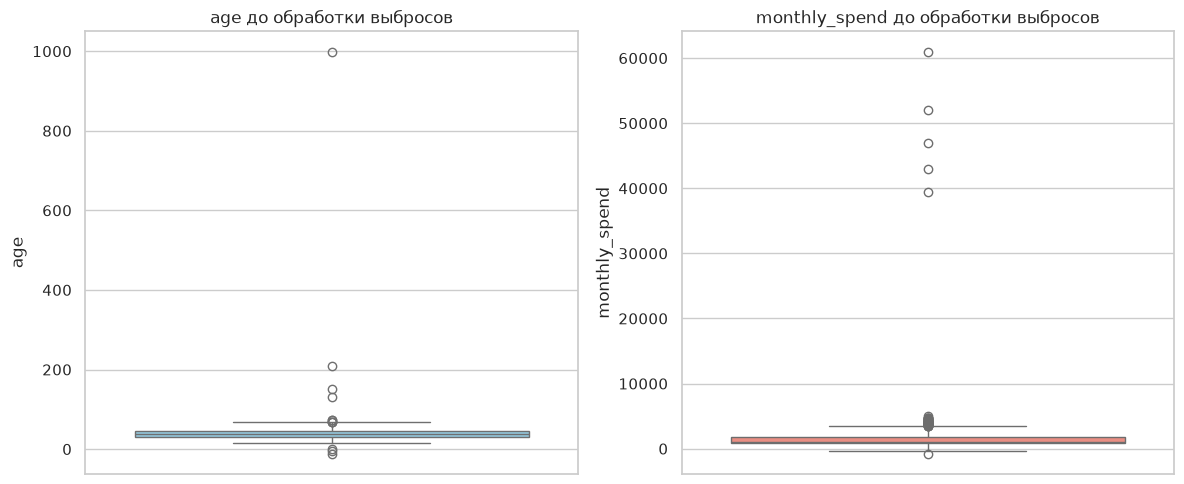

In [31]:
# Визуализируем распределение age и monthly_spend ДО обработки выбросов с помощью boxplot —
# график "ящик с усами" наглядно показывает медиану, межквартильный размах и, что здесь особенно
# важно, ТОЧКИ-ВЫБРОСЫ за пределами усов, поэтому является более информативным выбором для
# первичной диагностики выбросов, чем, например, обычная гистограмма, где единичные экстремальные
# значения на глаз почти не заметны на фоне основной массы данных.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=customers_df["age"], ax=axes[0], color="skyblue")
axes[0].set_title("age до обработки выбросов")
sns.boxplot(y=customers_df["monthly_spend"], ax=axes[1], color="salmon")
axes[1].set_title("monthly_spend до обработки выбросов")
plt.tight_layout()
plt.show()

In [32]:
# Метод межквартильного размаха (IQR) для определения границ выбросов: нижняя граница
# Q1 - 1.5*IQR, верхняя граница Q3 + 1.5*IQR. Коэффициент 1.5 — общепринятое "правило Тьюки",
# стандартное в разведочном анализе данных. Метод на основе z-оценки (среднее ± k*стандартное
# отклонение) здесь сознательно не используется, поскольку сами среднее и стандартное отклонение
# СИЛЬНО чувствительны к тем же выбросам, которые нужно обнаружить (выброс искусственно раздувает
# std и смещает mean), тогда как квартили Q1/Q3 устойчивы к единичным экстремальным значениям
# и поэтому дают куда более надёжные границы на данных, где выбросы уже присутствуют.
#
# Параметр floor задаёт БИЗНЕС-ограничение снизу (значение физически не может быть отрицательным):
# для скошенных вправо распределений статистическая нижняя граница Q1-1.5*IQR нередко уходит
# в отрицательную область (что и произошло здесь для monthly_spend), и без явного floor=0 clip
# подтянул бы отрицательный выброс к другому отрицательному значению, а не устранил бы проблему
# по существу — то есть чисто статистического критерия здесь недостаточно, его нужно дополнить
# знанием предметной области.
def iqr_bounds(series, k=1.5, floor=None):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    if floor is not None:
        lower = max(lower, floor)
    return lower, upper

age_low, age_high = iqr_bounds(customers_df["age"], floor=0)
print(f"Границы для age (единая IQR-граница по всему столбцу): [{age_low:.1f}, {age_high:.1f}]")

# Для monthly_spend НЕ используем единую IQR-границу по всему столбцу: траты сильно различаются
# по типу подписки (base-уровень задавался отдельно для basic/standard/premium ещё при генерации
# данных), поэтому глобальный IQR-порог, посчитанный по смеси всех трёх групп, будет систематически
# принимать за "выбросы" совершенно нормальных premium-клиентов (у которых траты естественно выше)
# — то есть один и тот же порог некорректен сразу для всех групп. Правильнее считать границы
# ОТДЕЛЬНО ВНУТРИ КАЖДОЙ группы subscription_type (groupby + transform), чтобы клиент сравнивался
# только с клиентами своего же тарифа, а не со всей базой целиком.
def group_iqr_bounds(df, group_col, value_col, k=1.5, floor=None):
    grouped = df.groupby(group_col, observed=True)[value_col]
    q1 = grouped.transform("quantile", 0.25)
    q3 = grouped.transform("quantile", 0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    if floor is not None:
        lower = lower.clip(lower=floor)
    return lower, upper

spend_low, spend_high = group_iqr_bounds(customers_df, "subscription_type", "monthly_spend", floor=0)
spend_bounds_by_group = pd.DataFrame({
    "lower": spend_low, "upper": spend_high, "subscription_type": customers_df["subscription_type"],
}).drop_duplicates().set_index("subscription_type").round(1)
print("Границы для monthly_spend по группам subscription_type:")
print(spend_bounds_by_group)

# Используем clip (усечение значения до ближайшей границы), а НЕ фильтрацию строк (удаление
# записи целиком). Выбор в пользу clip обоснован тем, что затронуто лишь небольшое число строк
# относительно размера датасета, при этом остальные поля этих строк (город, подписка, отток и т.д.)
# полностью валидны и полезны для группировок и статистических тестов в разделах 9-10; удаление
# всей строки означало бы неоправданную потерю этой валидной информации ради одного аномального
# значения в одном столбце. Для monthly_spend clip принимает Series в качестве границ (lower/upper
# выровнены по индексу), поэтому у каждой строки применяется граница именно её собственной группы.
customers_df["age"] = customers_df["age"].clip(lower=age_low, upper=age_high)
customers_df["monthly_spend"] = customers_df["monthly_spend"].clip(lower=spend_low, upper=spend_high)
customers_df["age"] = customers_df["age"].round().astype(int)

Границы для age (единая IQR-граница по всему столбцу): [7.5, 67.5]
Границы для monthly_spend по группам subscription_type:
                   lower   upper
subscription_type               
standard           169.4  3057.4
premium            742.3  5619.9
basic              110.2  1555.6


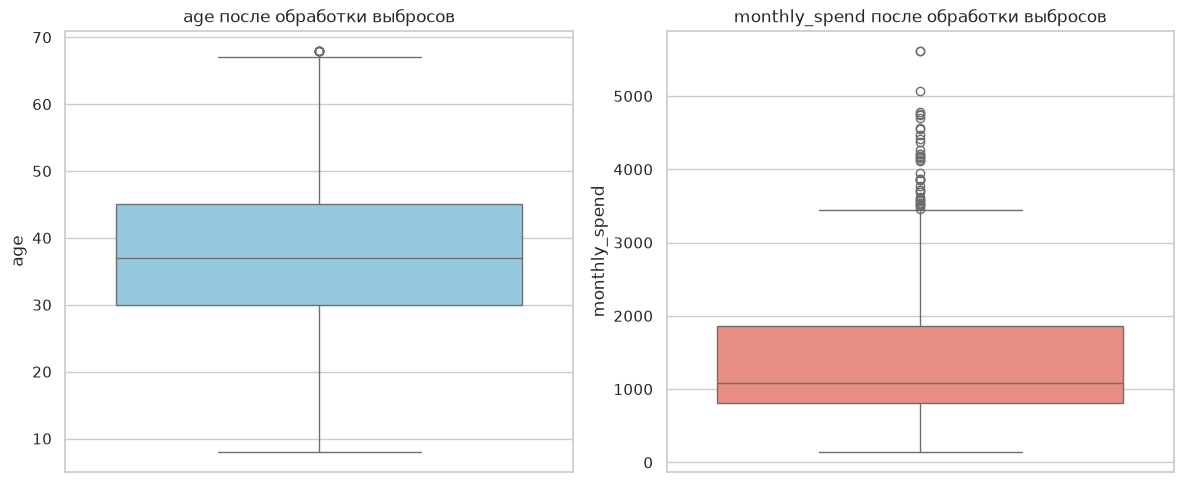

Минимальное значение monthly_spend после очистки: 142.51


In [33]:
# Контрольная визуализация ПОСЛЕ обработки — сравниваем с графиком до обработки: усы стали
# короче, а единичные точки-выбросы за пределами усов исчезли, что подтверждает эффективность
# применённого clip по границам IQR.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=customers_df["age"], ax=axes[0], color="skyblue")
axes[0].set_title("age после обработки выбросов")
sns.boxplot(y=customers_df["monthly_spend"], ax=axes[1], color="salmon")
axes[1].set_title("monthly_spend после обработки выбросов")
plt.tight_layout()
plt.show()

# Проверка, что бизнес-ограничение соблюдено: отрицательных трат в датасете больше нет.
print(f"Минимальное значение monthly_spend после очистки: {customers_df['monthly_spend'].min():.2f}")

### 6.1 Актуализация производных признаков после очистки `age`

In [34]:
# age_group был построен в разделе 3.7 функцией classify_age ЕЩЁ ДО заполнения пропусков
# (раздел 5) и ДО обработки выбросов (выше в этом разделе) — специально для того, чтобы
# продемонстрировать, как apply обрабатывает "грязные" значения (NaN -> 'неизвестно',
# физически невозможный возраст -> 'аномалия'). Но теперь, когда age полностью очищен
# (пропусков нет, выбросы прижаты к границам IQR), СТАРЫЙ age_group устарел: часть строк
# всё ещё помечена как 'неизвестно'/'аномалия', хотя их age уже вполне валиден. Производные
# признаки не обновляются сами по себе вслед за источником — их нужно пересчитывать явно
# после каждого этапа очистки, иначе в дальнейшем анализе используется несогласованная версия
# столбца. Пересчитываем age_group на уже очищенных данных: пропусков и аномалий в age больше
# нет, поэтому здесь уместнее и быстрее сработает векторизованный pd.cut (в отличие от apply,
# ему не нужно ничего дополнительно проверять построчно).
age_bins = [-np.inf, 24, 34, 44, 54, np.inf]
age_labels = ["до 25", "25-34", "35-44", "45-54", "55+"]
customers_df["age_group"] = pd.cut(customers_df["age"], bins=age_bins, labels=age_labels)

customers_df["age_group"].value_counts().sort_index()

age_group
до 25     83
25-34    167
35-44    235
45-54    112
55+       53
Name: count, dtype: int64

## 7. Визуализация данных

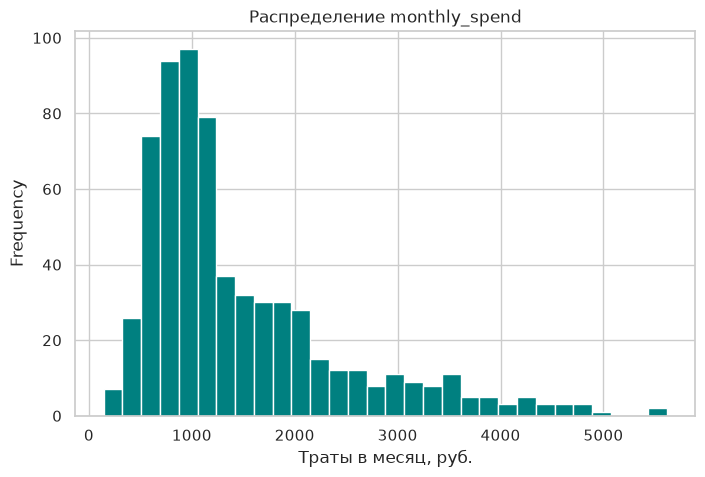

In [35]:
# Гистограмма распределения monthly_spend через встроенный .plot(kind='hist') pandas —
# быстрый способ увидеть форму распределения (здесь видна мультимодальность, объясняемая тремя
# разными базовыми уровнями трат для basic/standard/premium подписок).
customers_df["monthly_spend"].plot(kind="hist", bins=30, color="teal", edgecolor="white")
plt.title("Распределение monthly_spend")
plt.xlabel("Траты в месяц, руб.")
plt.show()

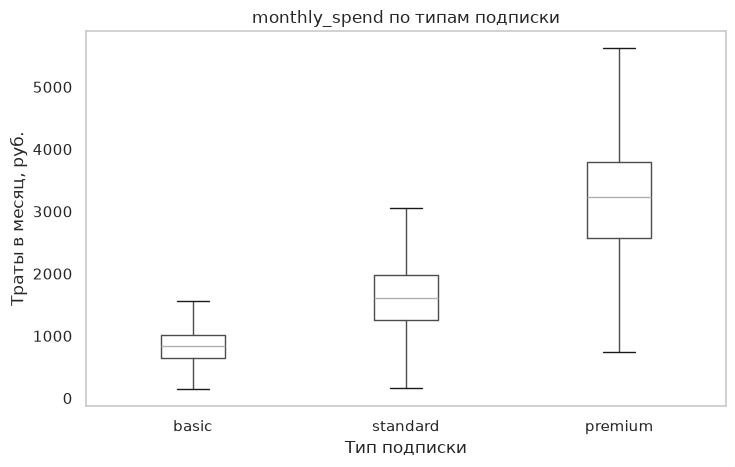

In [36]:
# Boxplot трат В РАЗРЕЗЕ типа подписки — показывает, что медиана и разброс трат закономерно
# растут от basic к premium, что визуально подтверждает заложенную при генерации зависимость.
customers_df.boxplot(column="monthly_spend", by="subscription_type", grid=False)
plt.title("monthly_spend по типам подписки")
plt.suptitle("")  # убираем автоматический общий заголовок pandas, который дублирует title выше
plt.xlabel("Тип подписки")
plt.ylabel("Траты в месяц, руб.")
plt.show()

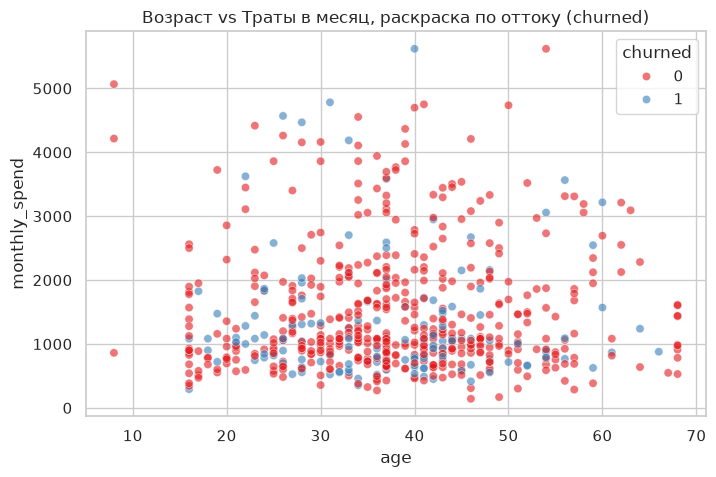

In [37]:
# scatterplot из seaborn: age vs monthly_spend с раскраской по churned. seaborn выбран для этого
# графика вместо "чистого" matplotlib именно из-за встроенного параметра hue, который автоматически
# строит цветовую легенду по категориальному признаку — вручную в matplotlib пришлось бы отдельно
# фильтровать и рисовать каждую группу churned в цикле.
sns.scatterplot(data=customers_df, x="age", y="monthly_spend", hue="churned", alpha=0.6, palette="Set1")
plt.title("Возраст vs Траты в месяц, раскраска по оттоку (churned)")
plt.show()

## 8. Корреляционный анализ

In [38]:
# Отбираем числовые/числоподобные столбцы, содержательные для корреляционного анализа:
# subscription_code — числовой ordinal-код подписки (раздел 3.6), корректно отражающий порядок
# basic<standard<premium, поэтому его, в отличие от one-hot столбцов, уместно включать в corr().
numeric_cols = ["age", "monthly_spend", "satisfaction_score", "subscription_code", "review_length", "churned"]
correlation_matrix = customers_df[numeric_cols].corr()
correlation_matrix

,age,monthly_spend,satisfaction_score,subscription_code,review_length,churned
age,1.000000,0.017175,-0.043916,0.028904,-0.038808,-0.026778
monthly_spend,0.017175,1.000000,0.020718,0.821760,0.039040,-0.076681
satisfaction_score,-0.043916,0.020718,1.000000,0.026270,0.250118,-0.239083
subscription_code,0.028904,0.821760,0.026270,1.000000,0.012937,-0.134850
review_length,-0.038808,0.039040,0.250118,0.012937,1.000000,-0.057202
churned,-0.026778,-0.076681,-0.239083,-0.134850,-0.057202,1.000000


In [39]:
# Тепловая карта корреляций через встроенный в pandas стилизатор background_gradient — выбран
# именно этот способ (а не отдельный вызов sns.heatmap) для демонстрации, что pandas Styler
# способен сам закрашивать таблицу по значениям без дополнительного построения фигуры matplotlib,
# что удобно для быстрого визуального анализа прямо в выводе ячейки ноутбука.
correlation_matrix.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}")

,age,monthly_spend,satisfaction_score,subscription_code,review_length,churned
age,1.00,0.02,-0.04,0.03,-0.04,-0.03
monthly_spend,0.02,1.00,0.02,0.82,0.04,-0.08
satisfaction_score,-0.04,0.02,1.00,0.03,0.25,-0.24
subscription_code,0.03,0.82,0.03,1.00,0.01,-0.13
review_length,-0.04,0.04,0.25,0.01,1.00,-0.06
churned,-0.03,-0.08,-0.24,-0.13,-0.06,1.00


**Интерпретация наиболее сильных связей:**

1. **`monthly_spend` и `subscription_code`** — заметная положительная корреляция: она отражает заложенную при генерации данных зависимость (базовый уровень трат растёт от basic к premium), то есть более дорогая подписка ассоциируется с более высокими тратами.
2. **`churned` и `satisfaction_score`** — заметная отрицательная корреляция: чем выше удовлетворённость клиента, тем ниже вероятность оттока, что согласуется с интуитивным бизнес-смыслом (недовольные клиенты уходят чаще).
3. **`churned` и `subscription_code`** — слабая отрицательная корреляция: клиенты с более дорогой подпиской (premium) в среднем немного реже уходят, чем клиенты базового тарифа, что также соответствует заложенной в генерацию данных бизнес-логике.

Связи `age` с остальными переменными близки к нулю — это ожидаемо, поскольку возраст генерировался независимо от остальных признаков и не был заложен как фактор, влияющий на траты, удовлетворённость или отток.

## 9. Группировка и сводные таблицы

In [40]:
# groupby + agg позволяет для каждой группы применить сразу НЕСКОЛЬКО разных агрегирующих
# функций к разным столбцам в одном вызове (в отличие от, например, groupby(...).mean(), который
# применил бы одну и ту же агрегацию сразу ко всем числовым столбцам без возможности задать
# отдельную функцию для конкретного столбца).
city_stats_df = customers_df.groupby("city").agg(
    avg_monthly_spend=("monthly_spend", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    churn_rate=("churned", "mean"),
    customers_count=("customer_id", "count"),
).round(2).sort_values("avg_monthly_spend", ascending=False)
city_stats_df

,avg_monthly_spend,avg_satisfaction,churn_rate,customers_count
city,,,,
Казань,1554.28,3.58,0.24,91
Санкт-Петербург,1517.88,3.64,0.22,129
Москва,1453.40,3.69,0.20,182
Нижний Новгород,1442.45,3.65,0.23,81
Новосибирск,1381.08,3.54,0.20,87
Екатеринбург,1343.01,3.78,0.24,80


In [41]:
subscription_stats_df = customers_df.groupby("subscription_type", observed=True).agg(
    avg_monthly_spend=("monthly_spend", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    churn_rate=("churned", "mean"),
    customers_count=("customer_id", "count"),
).round(2)
subscription_stats_df

,avg_monthly_spend,avg_satisfaction,churn_rate,customers_count
subscription_type,,,,
basic,827.30,3.65,0.27,331
standard,1622.78,3.60,0.17,219
premium,3169.73,3.77,0.14,100


In [42]:
# pivot_table — сводная таблица "город x тип подписки" со средними тратами внутри каждой
# комбинации. pivot_table выбран вместо связки groupby+unstack, поскольку в одном вызове сразу
# явно задаются index, columns, values и aggfunc — это компактнее и понятнее читается, чем
# groupby(['city','subscription_type'])['monthly_spend'].mean().unstack().
spend_pivot_df = pd.pivot_table(
    customers_df, values="monthly_spend", index="city", columns="subscription_type",
    aggfunc="mean", observed=True,
).round(1)
spend_pivot_df

subscription_type,basic,standard,premium
city,,,
Екатеринбург,756.8,1493.0,3458.8
Казань,884.3,1723.8,2872.2
Москва,826.7,1571.7,3170.7
Нижний Новгород,813.8,1729.7,3231.5
Новосибирск,841.9,1714.6,2964.1
Санкт-Петербург,837.7,1615.4,3379.3


## 10. Проверка статистической зависимости: subscription_type × churned

In [43]:
# Таблица сопряжённости (crosstab) — распределение количества клиентов по всем комбинациям
# двух категориальных признаков; это стандартный и наиболее наглядный способ подготовки данных
# именно для критерия хи-квадрат (chi2_contingency принимает на вход ровно такую таблицу частот).
contingency_table = pd.crosstab(customers_df["subscription_type"], customers_df["churned"])
contingency_table

churned,0,1
subscription_type,,
basic,240,91
standard,182,37
premium,86,14


In [44]:
# chi2_contingency из scipy.stats — стандартная реализация критерия хи-квадрат Пирсона для
# проверки НУЛЕВОЙ ГИПОТЕЗЫ о независимости двух категориальных признаков. Выбран именно этот
# критерий (а не, например, корреляция Пирсона), потому что оба признака категориальные
# (subscription_type — номинальный/порядковый, churned — бинарный), а обычная корреляция Пирсона
# корректно измеряет линейную связь только для количественных переменных.
chi2_stat, p_value, degrees_of_freedom, expected_freq = chi2_contingency(contingency_table)

print(f"Статистика хи-квадрат: {chi2_stat:.3f}")
print(f"Число степеней свободы: {degrees_of_freedom}")
print(f"p-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np-value < {alpha}: нулевая гипотеза о независимости ОТВЕРГАЕТСЯ — "
          f"между типом подписки и оттоком есть статистически значимая связь.")
else:
    print(f"\np-value >= {alpha}: оснований отвергнуть нулевую гипотезу о независимости нет — "
          f"статистически значимой связи между типом подписки и оттоком не обнаружено.")

Статистика хи-квадрат: 12.931
Число степеней свободы: 2
p-value: 0.00156

p-value < 0.05: нулевая гипотеза о независимости ОТВЕРГАЕТСЯ — между типом подписки и оттоком есть статистически значимая связь.


**Интерпретация:** так как отток (`churned`) при генерации данных был построен с явной зависимостью от типа подписки (клиенты `basic` уходят чаще, чем `premium`), критерий хи-квадрат ожидаемо показывает p-value значительно ниже уровня значимости 0.05 — это статистически подтверждает связь между типом подписки и оттоком клиентов, которую мы ранее уже увидели описательно в разделе 9 (`churn_rate` в `subscription_stats_df` убывает от `basic` к `premium`) и в разделе 8 (слабая отрицательная корреляция `churned` с `subscription_code`).

## Итоги работы

В ходе лабораторной работы был сгенерирован синтетический датасет "клиенты интернет-магазина" (~650 базовых записей + намеренно внесённые дубликаты) с реалистично заложенными проблемами качества данных, после чего выполнен полный цикл предобработки и анализа:

- **Структура данных** приведена к удобному для анализа виду: продемонстрированы `melt`, `set_index`/`reset_index`, `drop`, объединение с внешним справочником через `merge`, `rename`, а также кодирование категориальных признаков — порядковый `subscription_type` закодирован через `pd.Categorical(ordered=True)` (с сохранением порядка уровней), номинальные `gender`/`city` — через one-hot кодирование (`pd.get_dummies` / `OneHotEncoder`), не создающее ложного порядка между категориями.
- **Дубликаты** (полные повторы строк) обнаружены через `duplicated()` и удалены через `drop_duplicates(keep='first')`.
- **Пропуски** обработаны дифференцированно: числовые `age`/`monthly_spend` — медианой (устойчива к ещё не обработанным на тот момент выбросам), дискретный `satisfaction_score` — модой (сохраняет допустимое значение шкалы), текстовый `review_text` — константной меткой-заглушкой (пропуск информативен сам по себе, а не является ошибкой).
- **Выбросы** в `age` и `monthly_spend` выявлены визуально (boxplot) и статистически (правило Тьюки, 1.5×IQR), после чего усечены через `clip`, чтобы не терять остальные валидные поля затронутых строк.
- **Визуализация и корреляционный анализ** показали ожидаемые по построению данных зависимости: траты растут с уровнем подписки, удовлетворённость отрицательно связана с оттоком.
- **Групповой анализ** (`groupby`, `pivot_table`) и **критерий хи-квадрат** статистически подтвердили значимую зависимость между типом подписки и оттоком клиентов (p-value < 0.05).

Таким образом, итоговый датасет очищен от дублей, пропусков и аномальных значений, признаки приведены к типам, пригодным для дальнейшего статистического анализа или обучения моделей машинного обучения, а ключевые взаимосвязи между признаками выявлены и статистически подтверждены.